# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the census dataset
2. My label is income_binary and I'm predicting whether a person's annual income is greater than $50,000
3. Some features I plan on using are education, race, and workclass
4. This could help the CDFI triage applications more efficiently and target outreach efforts toward individuals who may qualify for its financial programs.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
# YOUR CODE HERE
workclass_list = df['workclass'].dropna().unique().tolist()
race_list = df['race'].dropna().unique().tolist()

race_list

['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Inuit', 'Other']

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
# YOUR CODE HERE
# one-hot encoding on the column workclass
df['workclass'].fillna(value="unavailable", inplace=True)
df_workclass = pd.get_dummies(df['workclass'])
df = pd.concat([df,df_workclass], axis=1)
df.drop(columns=['workclass'], inplace=True)
# binary indicator for >50k as 1 and <=50k as 0
# Map text directly to 0 and 1 in a single target column
df['income_binary'] = df['income_binary'].map({'<=50K': 0, '>50K': 1})
# find the correlation between each workclass and the income
correlations = df[workclass_list].corrwith(df['income_binary']).sort_values()
df.head()

,age,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,...,income_binary,Federal-gov,Local-gov,Never-worked,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Without-pay,unavailable
0,39.0,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,...,0,0,0,0,0,0,1,0,0,0
2,38.0,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,...,0,0,0,0,1,0,0,0,0,0
3,53.0,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,...,0,0,0,0,1,0,0,0,0,0
4,28.0,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,...,0,0,0,0,1,0,0,0,0,0


In [5]:
# YOUR CODE HERE
# one-hot encoding on the column g
df['race'].fillna(value="unavailable", inplace=True)
df_race = pd.get_dummies(df['race'])
df = pd.concat([df,df_race], axis=1)
df.drop(columns=['race'], inplace=True)

# find the correlation between each workclass and the income
correlation_race= df[race_list].corrwith(df['income_binary']).sort_values()
df.head()

,age,fnlwgt,education,education-num,marital-status,occupation,relationship,sex_selfID,capital-gain,capital-loss,...,Self-emp-inc,Self-emp-not-inc,State-gov,Without-pay,unavailable,Amer-Indian-Inuit,Asian-Pac-Islander,Black,Other,White
0,39.0,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Non-Female,2174,0,...,0,0,1,0,0,0,0,0,0,1
1,50.0,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Non-Female,0,0,...,0,1,0,0,0,0,0,0,0,1
2,38.0,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Non-Female,0,0,...,0,0,0,0,0,0,0,0,0,1
3,53.0,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Non-Female,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,...,0,0,0,0,0,0,0,1,0,0


In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


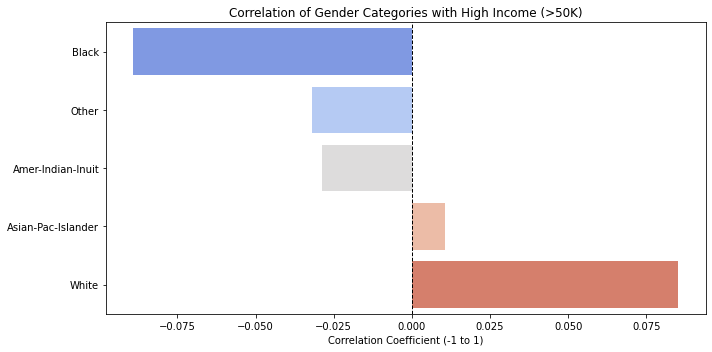

In [7]:
# graph each workclass
plt.figure(figsize=(10, 5))
sns.barplot(x=correlation_race.values, y=correlation_race.index, palette='coolwarm')

plt.title('Correlation of Gender Categories with High Income (>50K)')
plt.xlabel('Correlation Coefficient (-1 to 1)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) 
plt.tight_layout()
plt.show()

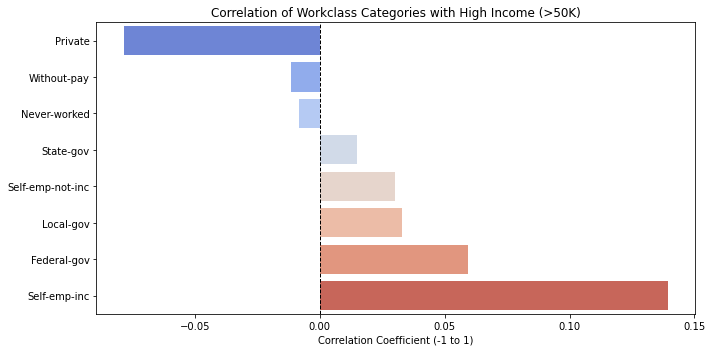

In [8]:
# graph each gender
plt.figure(figsize=(10, 5))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.title('Correlation of Workclass Categories with High Income (>50K)')
plt.xlabel('Correlation Coefficient (-1 to 1)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Center line
plt.tight_layout()
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

I first made a list of all the unique values in the column 'workclass' and then I one-hot encoded that column. Then I did binary indicator for >50k as 1 and <=50k as 0 and found the correlation between each workclass and the income. Finally, I plotted a bar graph which showed the correlation between each type of workclass and their income along with gender.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. Some biases could be that with race and gender because depending on who collected the data, there could be surplus amount of data for white people and not enough data for minorities which could lead to a skewed dataset. Same goes for gender if one gender is more represented than the other. 
2. People that are less represented by the data can be harmed because if a skewed model is created then not enough qualified people will qualify for the financial program. Groups such as low-income earners and self-employed individuals could be at risk.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [9]:
# for each missing value in each columns, comupute the mean to fill in thise values
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])


age               162
hours-per-week    325
dtype: int64


In [10]:
# YOUR CODE HERE
feature_list = df.select_dtypes(include=["number"]).columns.tolist()
feature_list.remove("income_binary")
feature_list
# for each missing value in each columns, comupute the mean to fill in thise values
for col in feature_list:
    mean_value = df[col].mean()
    df[col].fillna(value=mean_value, inplace = True)
    
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])
df[feature_list]

Series([], dtype: int64)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,Federal-gov,Local-gov,Never-worked,Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516,13,2174,0,40.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311,13,0,0,13.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721,7,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409,13,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,257302,12,0,0,38.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32557,40.0,154374,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32558,58.0,151910,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32559,22.0,201490,9,0,0,20.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

First, I decided to use Logistic Regression Model. In order to use this model I had to get a list of all the numerical columns and average out all the missing values in those columns. I also one-hot encoded some of the features since they were categorical.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
# Create labeled examples from the dataset
# YOUR CODE HERE
y = df['income_binary']
X = df.drop(columns=['income_binary'])


In [12]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state= 1234)

In [13]:
# Train, test and evaluate your model
# YOUR CODE HERE
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
probability_predictions = model.predict_proba(X_test)
df_print = pd.DataFrame(probability_predictions, columns = ['Class: False', 'Class: True'])

class_label_predictions = model.predict(X_test)

# print the first 5 class label predictions 
print('Class labels: ' + str(class_label_predictions[0:5]))

# 6.Compute the accuracy score on 'class_label_predictions' and save the result 
# to the variable 'acc_score' below

# YOUR CODE HERE
acc_score = accuracy_score(y_test,class_label_predictions)
f1 = f1_score(y_test, class_label_predictions, average='binary')

print('Accuracy: ' + str(acc_score))
print('F1 score: ' + str(f1))

Class labels: [0 0 0 1 0]
Accuracy: 0.8002047273404057
F1 score: 0.3793003758311651


In [14]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
cs=[10**i for i in range(-5,5)]
param_grid = {"C":cs}
model = LogisticRegression()
grid = GridSearchCV(model, param_grid, cv=5)
grid_search = grid.fit(X_train, y_train)
# YOUR CODE HERE
print('Optimal hyperparameters: {0}'.format(grid_search.best_params_))

# print best accuracy score resulting from this configuration
print('Accuracy score: {0}'.format(grid_search.best_score_))

best_C  = grid_search.best_params_
best_C

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Optimal hyperparameters: {'C': 0.1}
Accuracy score: 0.800275040110016


{'C': 0.1}

In [15]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
# Note that k=5 is specifying that we want the top 5 features
selector = SelectKBest(f_classif, k=5)
selector.fit(X, y)
filter = selector.get_support()
top_5_features = X.columns[filter]

print("Best 5 features:")
print(top_5_features)

# Create new training and test data for features
new_X_train = X_train[top_5_features]
new_X_test = X_test[top_5_features]

best_model = LogisticRegression(max_iter=1000, C = 0.1)
best_model.fit(new_X_train, y_train)
probability_predictions = best_model.predict_proba(new_X_test)
df_print = pd.DataFrame(probability_predictions, columns = ['Class: False', 'Class: True'])

class_label_predictions = best_model.predict(new_X_test)



Best 5 features:
Index(['age', 'education-num', 'capital-gain',
       'marital-status_Married-civ-spouse', 'marital-status_Never-married'],
      dtype='object')


In [16]:
# Interpret your model's outputs 
# YOUR CODE HERE
# print the first 5 class label predictions 
print('Class labels: ' + str(class_label_predictions[0:5]))

# 6.Compute the accuracy score on 'class_label_predictions' and save the result 
# to the variable 'acc_score' below

# YOUR CODE HERE
acc_score = accuracy_score(y_test,class_label_predictions)
print('Accuracy: ' + str(acc_score))
f1 = f1_score(y_test, class_label_predictions, average='binary')
print("F1 Score:", f1)

Class labels: [1 1 0 1 0]
Accuracy: 0.8324027545133073
F1 Score: 0.5951899303214205


In [17]:
coef_df = pd.DataFrame({
    "Feature": new_X_train.columns,
    "Coefficient": best_model.coef_[0]
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

                             Feature  Coefficient
3  marital-status_Married-civ-spouse     2.279583
1                      education-num     0.388065
0                                age     0.021390
2                       capital-gain     0.000336
4       marital-status_Never-married    -0.562725


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose a Logistic Regression model beacuse my problem was a Binary Classification probelem, so this model would be better suited. The problem also predicts whether a person's annual income is greater than \$50,000 which is categorical and not a continuous number. My label is a binary column as well which makes a Logistic Regression model a better choice.
2. I had to think about what I needed to do to prepare my data for the model. I had to use one-hot encoding to change some of the categorical columns into binary.
3. I found the top 5 features which were age, education-num, capital-gain, capital-loss, hours-per-week. This showed that those features had the most affect on whether a person's annual income was greater than $50,000. The accuracy was 0.81583845151684344 which is pretty solid baseline for the model. 
4. When I one-hot encoded the race columns I expected there to be a little more diversity for the races that we had. I also thought that it would be included in the top 5 features. This makes me reconsider whether this dataset was diverse enough because if it's not then it skews the results of the model and groups that are less represented won't have accurate predictions which can affect whether they qualify for the financial program.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [18]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()


# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(new_X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(new_X_test)


### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [19]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
# input_shape should be the number of features you have
input_layer = keras.layers.InputLayer(input_shape = 5)
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?

# I did 2 hidden layers to start off since we have a simpler neural network 
# I chose to use units 64, 32 and 16 because the problem is a standard binary classification problem so I don't need a very in depth network
# I used relu for the hidden layers because its allows the gradient to remain large enough for effective learning and its faster to train
# I used sigmoid for the output layer because it produces an output between 0 and 1 which suits binary classification

# YOUR CODE HERE

hidden_layer_1 = keras.layers.Dense(units = 64, activation = 'relu')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units = 16, activation = 'relu')
nn_model.add(hidden_layer_2)


hidden_layer_3 = keras.layers.Dense(units = 8, activation = 'relu')
nn_model.add(hidden_layer_3)


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE

output_layer = keras.layers.Dense(units = 1, activation ='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                384       
_________________________________________________________________
dense_1 (Dense)              (None, 16)                1040      
_________________________________________________________________
dense_2 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 9         
Total params: 1,569
Trainable params: 1,569
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [20]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# I chose 0.01 since its a common starting point and 0.1 could be too high making the traning unstable

sgd_optimizer = keras.optimizers.SGD(learning_rate = 0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [21]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [22]:
# YOUR CODE HERE
nn_model.compile(optimizer = sgd_optimizer, loss = loss_fn, metrics =['accuracy'])


### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [23]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [24]:
# Decision: How many epochs? Add a comment.
# I chose 20 epochs since I'm only using 5 features and my dataset isn't too big. Also to reduce the chance of overfitting. 

t0 = time.time() # start time

num_epochs = 20

history = nn_model.fit(
    X_train_scaled, 
    y_train, 
    epochs=num_epochs, 
    validation_split=0.2, 
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=1)]
)
t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/20
546/546 [==============================] - 3s 4ms/step - loss: 0.4726 - accuracy: 0.7760 - val_loss: 0.3726 - val_accuracy: 0.8050
Epoch [1/ 20], Loss: 0.4726, Accuracy: 0.7760, Val_loss: 0.3726, Val_accuracy: 0.8050
Epoch 2/20
546/546 [==============================] - 1s 2ms/step - loss: 0.3563 - accuracy: 0.8307 - val_loss: 0.3407 - val_accuracy: 0.8402
Epoch [2/ 20], Loss: 0.3563, Accuracy: 0.8307, Val_loss: 0.3407, Val_accuracy: 0.8402
Epoch 3/20
546/546 [==============================] - 1s 2ms/step - loss: 0.3387 - accuracy: 0.8425 - val_loss: 0.3369 - val_accuracy: 0.8396
Epoch [3/ 20], Loss: 0.3387, Accuracy: 0.8425, Val_loss: 0.3369, Val_accuracy: 0.8396
Epoch 4/20
546/546 [==============================] - 1s 2ms/step - loss: 0.3353 - accuracy: 0.8423 - val_loss: 0.3351 - val_accuracy: 0.8419
Epoch [4/ 20], Loss: 0.3353, Accuracy: 0.8423, Val_loss: 0.3351, Val_accuracy: 0.8419
Epoch 5/20
546/546 [==============================] - 1s 3ms/step - loss: 0.3337 - accur

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



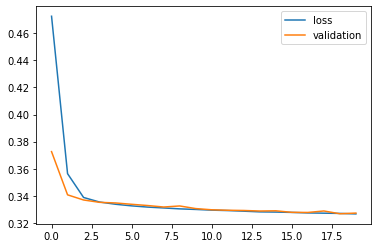

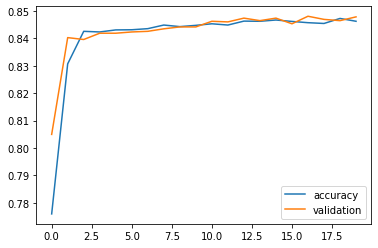

In [25]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()



# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE


plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [26]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE
class_label_predictions_new = nn_model.predict(X_test_scaled)
class_label_predictions_new = (class_label_predictions_new >= 0.5).astype(int)

In [27]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE
new_acc_score = accuracy_score(y_test,class_label_predictions_new)
new_f1 = f1_score(y_test, class_label_predictions_new, average='binary')

print('Accuracy: ' + str(new_acc_score))
print('F1 score: ' + str(new_f1))

Accuracy: 0.8380792853154663
F1 score: 0.6233766233766234


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. At first I did 2 hidden layers and got an accuracy of 0.8406 and f1 score of 0.6129. Then I added another hidden layer and got an accuracy of 0.8387 and f1 score of 0.6210. This f1 score increased while the accuracy is a little lower, but I think in this instance the accuracy is still pretty good so the increased f1 score would be better. For the number of units I did 64, 32, and 8 which is pretty standard. The activation function I used for the hidden layers was relu because its faster to train and sigmoid for the output layer because that's better for binary classification problems. The learning rate I chose was 0.01 since its a good starting rate and when I tried to use 0.001, the accuracy and f1 score decreased. For the number of epochs, I chose 20 because the datatset given isn't huge and when I did 30 the accuracy and f1 wasn't as good as 20 epochs.
2. The validation didn't start increasing and went down in a general downward direction. The accuracy and validation both didn't decrease. The training and validation were pretty close to each other which is a good sign. 
3. My nueral network prefored pretty well on the test set. It got an accuracy of 0.8380 and f1 score of 0.6233. This is better than my logistic regression model that got an accuracy of 0.8324 and f1 score of 0.5951. I was surpised at how the graph depicts the accuracy since it looked a little bumbpy on the graphs but the actual score was pretty solid.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [29]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [acc_score, f1],
    'Neural Network': [new_acc_score, new_f1]
})
print(results.to_string(index=False))
#
# YOUR CODE HERE

   Metric  Logistic Regression  Neural Network
 Accuracy             0.832403        0.838079
 F1 Score             0.595190        0.623377


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The neural network performed better than the logistic regression with both the accuracy and f1 score being better as well.
2. I think the added complexity was worth it because the f1 score shows more promising results of accurate postive class. I think with even more complex data a nueral network only prove more beneficial. It did take a bit of tuning to make sure I got the best reuslts I could but the result gave a better performing model. 
3. I would stick with Logistic Regression since it's easier to explain to people who don't have a background in ML. I think the training time is more costly for neural networks and the more data and features you have the more costly it will get which is probably something many businesses have. 
4. I would try to test different pre-processing techniques to improve the model and with that possibly select better features that are less noisy and align with the label better. I would also test out different parameters for the GridSearch to find the optimal ones.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used ChatGPT to help get started with what to do for my preprocssing stage. At first I only preprocessed a few features which gave more poor accuracy and f1 scores so I used AI to help my find the root cause of what was giving me those poor scores in the preprocssing step. I also used AI to help me understand what parameters (layers, units, activation function, learning rate) to choose and why. I used AI to help my develop the graphs since I wasn't sure on the correct inputs the graph needed.
2. The beginning stage of getting the data ready and creating the logistic regression model was the hardest because I wasn't sure what to fix in my data or how to go about preprocessing since there wasn't any instructions telling me what to do. I used AI for this step and used prompts such as, "For this dataset, what preprocessing steps could I use?" and this gave me one-hot encoding for the features and binary indicator for the label. This helped me move in the right direction.
3. To verify my work, my accuracy and f1 scores helped me figure out if my model was preforming well and if they were low then that told me there was something wrong in one of my previous steps. My graph at first also looked completly wrong which signaled that there was something wrong. ChatGPT would output some print statments that would show whether the output of a varible was accurate. 
4. I would probably spend more time making sure my preprocssing was done correctly since it can cause a lot of issues down the road.